# Lesson 06b: The Tetris Example

**What you will learn**

- Batching several small graphs into one by using the index-offset trick
- Why a model, whose output contains only **true scalars (`0e`)**, cannot
  distinguish mirror-image shapes in the 3D Tetris dataset, and how using a
  **pseudoscalar (`0o`)** output fixes this issue
- The **augmentation-free rotation test**: train on one orientation, evaluate on
  random rotations
- Bonus: Inverting the shapes swaps the chiral pair's predictions due to
  equivariance acting on *labels*.

**Prerequisites:** 

- Lesson 02a: Parity
- Lessons 04, 05a, and 05b,: gates,
- Lesson 06a: The `TFNConv` block,

In [1]:
import sys
sys.path.insert(0, "..")

import math

import matplotlib.pyplot as plt
import numpy as np
import torch
from e3nn import o3, nn as enn

from course_utils.data import radius_graph, tetris, TETRIS_LABELS
from course_utils.equivariance import assert_model_equivariant
from course_utils.plotting import (scene3d, draw_point_cloud, show3d,
                                    plot_training_curves)

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)  # tiny model: keep the precision, verify equivariance
device = torch.device("cpu")            # 32 atoms total - CPU is instant
print(f"torch {torch.__version__}")

torch 2.7.1+cu126


## The 3D Tetris dataset: Eight shapes, one chiral pair

The 3D Tetris dataset offers a classic e3nn exercise where the an equivariant
model is tasked to classify eight 3D "Tetris" shapes. The course provides a
convenience function to create the Tetris dataset: `course_utils.data.tetris()`
returns eight shapes, each made out of four unit blocks, representing a point
cloud of 4 atoms per shape. Shapes 0 and 1, `chiral_shape_1` and
`chiral_shape_2`, are **mirror images** of each other: no rotation or
translation maps one onto the other, only an *improper* operation
(reflection/inversion) does.

> **Note**: Any network that relies solely upon distances (such as SchNet) or
angles between points (such as ANI-1) cannot distinguish the chiral shapes from
each other but equivariant models such as tensor field networks (TFNs) can.

> **Note**: The `tetris()` coordinates are copied row-for-row from the [reference
code](https://github.com/tensorfieldnetworks/tensorfieldnetworks)'s
`shape_classification.ipynb`; only three names differ — the repo's
`T`/`zigzag`/`L` labels are our `L`/`T`/`zigzag` (we keep the e3nn tutorial's
naming, which matches the geometry).

We should also point out that the TFN is formulated for **SO(3)** (rotations
only). Thus, chirality-sensitivity comes for free in its $l=0$ outputs. e3nn
works with the full **O(3)** and tracks parity explicitly (Lesson 02a). So,
chirality-sensitivity must be *declared*, by giving the output a pseudoscalar
`0o` slot. That distinction is the whole point of this lesson.

Let us look at the shapes in the 3D Tetris dataset. 

In [2]:
# Load the 3D Tetris dataset
# (8, 4, 3), (8, 8)
pos8, labels_onehot = tetris()
print("shapes:", TETRIS_LABELS)

# Visualize the 8 Tetris shapes
# Unit blocks: catches side (1.0) + diagonal (sqrt 2) pairs
r_cut = 1.5

# Chirality is the whole point here, and it only reads properly in 3D
fig = scene3d(2, 4, titles=[f"{k}: {TETRIS_LABELS[k]}" for k in range(len(pos8))])

for k, p in enumerate(pos8):
    draw_point_cloud(p, fig=fig, cell=(k // 4 + 1, k % 4 + 1),
                     color="tab:red" if k < 2 else "C0", edges=radius_graph(p, r_cut))

show3d(fig, title="the 8 Tetris shapes (red: the chiral mirror pair)", legend=False)

shapes: ['chiral_shape_1', 'chiral_shape_2', 'square', 'line', 'corner', 'L', 'T', 'zigzag']


<plotly figure: the 8 Tetris shapes (red: the chiral mirror pair)>

## Batching the eight graphs

The whole dataset fits in one forward pass if we concatenate the graphs. The
node indices of shape $g$ are offset by the number of preceding nodes, and a
`batch` vector remembers which graph each node belongs to. Thus, we can pool
node features per graph at the end (mean over each shape's 4 blocks, which is a
linear and permutation-invariant operation) making the readout also equivariant.
Note that the global pooling operation, mentioned here, is equivariant because
D-matrices act linearly.

Let us see how to implement this batching trick.

In [3]:
# Batching the eight graphs
def batch_graphs(pos_list, r_cut):
    # Containers for positions, edges, and batch vectors
    positions, edges, batch, offset = [], [], [], 0
    # Iterate over each graph in the list
    for g, p in enumerate(pos_list):
        # Append the positions, edges, and batch vector for the current graph
        positions.append(p)
        edges.append(radius_graph(p, r_cut) + offset)
        batch.append(torch.full((len(p),), g, dtype=torch.long))
        # Update the offset for the next graph
        offset += len(p)
    # Concatenate the positions, edges, and batch vectors into single tensors
    return torch.cat(positions), torch.cat(edges, dim=1), torch.cat(batch)

# Batch the graphs and print the number of nodes, edges, and average degree
pos, edge_index, batch = batch_graphs(list(pos8), r_cut)
avg_neighbors = edge_index.shape[1] / len(pos)
print(f"batched: {len(pos)} nodes, {edge_index.shape[1]} edges, <deg> = {avg_neighbors:.2f}")
print(f"batch vector: {batch.tolist()}")

batched: 32 nodes, 78 edges, <deg> = 2.44
batch vector: [0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 6, 7, 7, 7, 7]


## Parity decides what is learnable

Let $f$ be *any* O(3)-equivariant model (such as the TFN variant we built in
Lesson 06a). Applied to a shape, $X = \{\vec r_a\}$, and its inversion, $-X$:

- if the output carries **true scalars** `0e`: $\;D^{(0,e)}(-\mathbb 1) = +1 \implies f(-X) = f(X)$;
- if the output carries a **pseudoscalar** `0o`: $\;D^{(0,o)}(-\mathbb 1) = -1 \implies f(-X) = -f(X)$.

Shape 1 is (up to rotation and translation, which leave the shape unchanged)
exactly the mirror image of shape 0, i.e., $-X_0$. So a `0e`-only model gives
**bit-identical outputs for the chiral pair, before, during, and after
training.** No loss function can fix an architecture-level identity. A `0o`
output, by contrast, is *forced* to take opposite signed values on the pair.

## Targets

Following the e3nn Tetris example, we make the first entry of the output layer
(out of 7, each for a different shape/class) a pseudoscalar and regress the
signed target values with mean-squared error (MSE). Hence, the output irreps
become `1x0o + 6x0e` (7 numbers):

| shape | target |
|---|---|
| 0 `chiral_shape_1` | $(-1, 0, 0, 0, 0, 0, 0)$ |
| 1 `chiral_shape_2` | $(+1, 0, 0, 0, 0, 0, 0)$ |
| $k = 2 \ldots 7$ | $+1$ in `0e` slot $k-1$ |

The model classifies the shapes by the nearest target vector based on the MSE.

Instead of using 7 numbers in the output layer as described above, why not using
8 softmax logits? In the original code, using the softmax trick was legal
because under SO(3), the model never sees the inversion, and TFN's $l=0$ readout
quietly contains the triple-product quantities that O(3) classifies as
pseudoscalars such as $\vec{a} \cdot (\vec{b} \times \vec{c})$. However, the
softmax trick is not O(3)-equivariant and will fail if the model is evaluated on
inverted shapes. In e3nn's O(3) bookkeeping, the cross-entropy logits would also
be an 8 *invariant* `0e` set of scalars which will be confused on the chairal
pair.

Note that the shape label set itself transforms under inversion: mirroring the
shape 0 should yield the prediction shape 1. The signed pseudoscalar target
makes that covariance explicit.

In [4]:
# Create the target tensor for the 8 Tetris shapes
targets = torch.zeros(8, 7)

# Insert the chiral pair targets for the first two shapes (0 and 1) as
# pseudoscalars
targets[0, 0], targets[1, 0] = -1.0, 1.0

# Everything other shape: one-hot in the 0e slots
for k in range(2, 8):
    targets[k, k - 1] = 1.0                

# Define the classification function based on the nearest target vector
def classify(out):
    return (out[:, None, :] - targets[None, :, :]).norm(dim=-1).argmin(dim=1)

# Define the accuracy function to compute the mean accuracy of the model's
# predictions
def accuracy(out):
    return (classify(out) == torch.arange(8)).double().mean().item()

## The network

The radial part of the TFN filters (the product of a **learned radial function**
and a **spherical harmonic**) come from Lesson 05b, which we reproduce here for
completeness.

In [5]:
class BesselBasis(torch.nn.Module):
    """Lesson 05b, (DimeNet) basis functions."""

    def __init__(self, r_cut, n_basis=8):
        super().__init__()
        self.prefactor = math.sqrt(2.0 / r_cut)
        self.register_buffer("k_n", torch.arange(1, n_basis + 1) * math.pi / r_cut)

    def forward(self, d):
        d = d.unsqueeze(-1)
        return self.prefactor * torch.sin(self.k_n * d) / d


class PolynomialCutoff(torch.nn.Module):
    """Lesson 05b, (DimeNet) with d -> d/r_cut."""

    def __init__(self, r_cut, p=6):
        super().__init__()
        self.r_cut, self.p = r_cut, p

    def forward(self, d):
        x, p = d / self.r_cut, self.p
        u = (1.0 - (p + 1) * (p + 2) / 2 * x**p + p * (p + 2) * x**(p + 1)
             - p * (p + 1) / 2 * x**(p + 2))
        return torch.where(d < self.r_cut, u, torch.zeros_like(d))

In the previous section ([Targets](#Targets)), we fixed the readout irreps to
`1x0o + 6x0e`, so that the model can distinguish the chiral pair using the
pseudoscalar output (`0o`). However, the network starts from *featureless*
nodes: every block carries the same constant `0e` scalar (the `h =
torch.ones(...)` line in `TetrisNet.forward` method). As such, an important part
of the model's prediction capacity should come from discerning the *geometry* of
the shape, not from any initial node features. 

Consequently, the model must *manufacture* the pseudoscalar output from
coordinates alone. We do this by stacking `TFNConv` layers from Lesson 06a with
`Gate` nonlinearities in between, and this section shows that the stack must be
exactly **three** layers deep. The depth is not a hyperparameter choice; it is
dictated by parity selection rules.

Recall what one `TFNConv` layer computes: its `FullyConnectedTensorProduct`
combines the incoming node features with the spherical harmonics of the edge
vectors, $Y^{(l)}(\hat r_{ij})$. The harmonics carry the *natural* parities $(l,
(-1)^l)$, so with $l_\text{max} = 2$, every filter irrep is `0e`, `1o`, or `2e`,
and each output path's parity becomes the product of its two input parities. The
only odd-parity filter is `1o` which corresponds to the edge direction itself.

The chain below tracks the one path that leads to the pseudoscalar (each layer
produces many other, even-parity irreps alongside it). Here, every "$\otimes\;
1o$" is one convolution layer mixing in one more edge direction:

$$
\underbrace{0e \otimes 1o \to 1o}_{\text{layer 1: vectors}} \qquad
\underbrace{1o \otimes 1o \to 1e}_{\text{layer 2: pseudovectors}} \qquad
\underbrace{1e \otimes 1o \to 0o}_{\text{layer 3: pseudoscalar}}
$$

Each step of the chain corresponds to one line of `TetrisNet.__init__` below:

- **Layer 1** (`conv1` + `gate1`): The constant scalars meet the first edge
  direction; the odd-parity output is an ordinary vector, hence the `8x1o` in
  `gate1`'s gated irreps. Nothing is chiral yet as a single direction cannot
  tell left from right.
- **Layer 2** (`conv2` + `gate2`): The layer-1 vectors are *crossed* with a
  second edge direction: `1o` $\otimes$ `1o` $\to$ `1e`, a **pseudovector**:
  think $\vec r_1 \times \vec r_2$. This is the first irrep in the network whose
  parity disagrees with the natural $(-1)^l$, and it is why `gate2`'s gated
  irreps read `8x1o + 8x1e + 8x2e` (the `# Note the 1e!` comment in the code).
- **Layer 3** (`conv3`): The pseudovector is *dotted* with a third direction,
  `1e` $\otimes$ `1o` $\to$ `0o`, landing exactly in the `0o` slot that the
  targets demand. Composed, the three layers build the scalar triple product
  $(\vec r_1 \times \vec r_2) \cdot \vec r_3$: the archetypal pseudoscalar, and
  the smallest geometric quantity that flips sign under reflection built from
  three edge directions.

Could two layers suffice to achieve this? No. To emit `0o` in a single tensor
product, the filter, which always has natural parity, must meet a feature whose
parity already disagrees with $(-1)^l$ (such as `1e`). Such "unnatural" features
can only be created by an earlier product of natural ones (`1o` $\otimes$ `1o`
$\to$ `1e`), which in turn needs the non-scalar `1o` features of a layer before
that. Hence, layer 2's hidden irreps must include `1e`, and $T = 3$ is the
minimum depth. (Exercise 1 severs this argument by deleting the `1e` and
watching the pseudoscalar output die.)

The original TFN network is also exactly three modules deep, with only $l \le 1$
filters: its $1 \otimes 1 \to 1$ path (the Levi-Civita $\epsilon_{ijk}$: a cross
product) composed with $1 \otimes 1 \to 0$ (a dot product) builds the same
triple product. The SO(3) group simply registers the result under plain $l = 0$
but the O(3) files it under `0o`.

Below, we reimplement the TFN convolution filter and then use it to build the
Tetris network.

In [13]:
class TFNConv(torch.nn.Module):
    """The equivariant point convolution assembled step-by-step in Lesson 06a."""

    def __init__(self, irreps_in, irreps_out, r_cut, l_max=2, n_basis=8, avg_neighbors=1.0):
        super().__init__()
        self.irreps_sh = o3.Irreps.spherical_harmonics(l_max)
        self.tp = o3.FullyConnectedTensorProduct(
            irreps_in, self.irreps_sh, irreps_out,
            shared_weights=False, internal_weights=False)
        self.basis, self.envelope = BesselBasis(r_cut, n_basis), PolynomialCutoff(r_cut)
        self.radial_mlp = enn.FullyConnectedNet(
            [n_basis, 16, self.tp.weight_numel], torch.nn.functional.silu)
        self.self_interaction = o3.Linear(irreps_out, irreps_out)
        self.norm = avg_neighbors ** 0.5

    def forward(self, h, edge_index, edge_vec):
        i, j = edge_index
        d = edge_vec.norm(dim=-1)
        Y = o3.spherical_harmonics(self.irreps_sh, edge_vec,
                                   normalize=True, normalization="component")
        u = self.envelope(d)
        w = self.radial_mlp(self.basis(d) * u.unsqueeze(-1))
        m = self.tp(h[j], Y, weight=w) * u.unsqueeze(-1)
        agg = torch.zeros(h.shape[0], m.shape[1], dtype=h.dtype, device=h.device)
        agg.index_add_(0, i, m)
        return self.self_interaction(agg / self.norm)

In [7]:
# Create the TetrisNet model, which stacks three TFNConv layers with Gate nonlinearities
class TetrisNet(torch.nn.Module):
    def __init__(self, irreps_out, r_cut, avg_neighbors):
        super().__init__()
        self.gate1 = enn.Gate("8x0e", [torch.nn.functional.silu],
                              "16x0e", [torch.sigmoid], "8x1o + 8x2e")
        self.gate2 = enn.Gate("8x0e", [torch.nn.functional.silu],
                              "24x0e", [torch.sigmoid], "8x1o + 8x1e + 8x2e")  # Note the 1e!
        self.conv1 = TFNConv("1x0e", self.gate1.irreps_in, r_cut, avg_neighbors=avg_neighbors)
        self.conv2 = TFNConv(self.gate1.irreps_out, self.gate2.irreps_in, r_cut,
                             avg_neighbors=avg_neighbors)
        self.conv3 = TFNConv(self.gate2.irreps_out, irreps_out, r_cut,
                             avg_neighbors=avg_neighbors)

    def forward(self, pos, edge_index, batch, n_graphs):
        # r_ij = r_j - r_i
        edge_vec = pos[edge_index[1]] - pos[edge_index[0]]
        # Identical blocks
        h = torch.ones(pos.shape[0], 1, dtype=pos.dtype, device=pos.device)
        h = self.gate1(self.conv1(h, edge_index, edge_vec))
        h = self.gate2(self.conv2(h, edge_index, edge_vec))
        h = self.conv3(h, edge_index, edge_vec)
        out = torch.zeros(n_graphs, h.shape[1], dtype=h.dtype, device=h.device)
        out.index_add_(0, batch, h)
        # Mean-pool the 4 blocks
        return out / 4.0

# Training function for the TetrisNet model
def train(model, steps=300, lr=0.02):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for _ in range(steps):
        opt.zero_grad()
        loss = ((model(pos, edge_index, batch, 8) - targets) ** 2).mean()
        loss.backward()
        opt.step()
        history.append(loss.item())
    return history

> **Note** The reference
[shape_classification.ipynb](https://github.com/tensorfieldnetworks/tensorfieldnetworks/blob/master/shape_classification.ipynb)
trains the network with an embedding self-interaction followed by three modules
of {all $l \le 1$ convolution paths $\to$ concatenation $\to$ self-interaction
$\to$ norm nonlinearity}, channel widths $[1, 4, 4, 4]$, on a fully connected
point cloud (no $r_\mathrm{cut}$) and using 4 Gaussian radial basis functions on
$[0, 3.5]$. Its readout mean-pools the $l = 0$ features into a dense layer
producing **8 softmax logits**, trained with cross-entropy (Adam, lr $10^{-3}$,
on roughtly 2000 epochs, one shape per step). We, however, use a signed-target
MSE (Adam, lr $0.02$, 300 full-batch steps).

Having implemented the `TetrisNet`, it may be instructive to perform a few
ablation experiments to see how the network behaves when we change the geometric
constraints in the architecture. 

## Experiment 1: The invariant model cannot distinguish the chiral pair

Here, we use the same architecture but the output irreps are changed to `1x0e +
6x0e` = `7x0e`: seven true scalars.

In [14]:
# Set the random seed for reproducibility
torch.manual_seed(1)

# Create an instance of the TetrisNet model with output irreps "7x0e" (seven true scalars)
model_inv = TetrisNet("7x0e", r_cut, avg_neighbors)
print(f"parameters: {sum(p.numel() for p in model_inv.parameters())}")

# Compute the outputs of the model for the two chiral shapes (0 and 1) 
out = model_inv(pos, edge_index, batch, 8)
gap = (out[0] - out[1]).abs().max().item()
print(f"untrained:  max |f(chiral_1) - f(chiral_2)| = {gap:.1e}   <- identical, as proved")

parameters: 28209
untrained:  max |f(chiral_1) - f(chiral_2)| = 0.0e+00   <- identical, as proved


The architecture-level identity shows that **before any training**, the outputs
for the two chiral shapes are already bit-identical. Let us now train the model
and see if it can learn to distinguish the pair.

final loss 0.0357,  accuracy 0.750
predictions: [6, 6, 2, 3, 4, 5, 6, 7]  (true: [0, 1, 2, 3, 4, 5, 6, 7])
trained:    max |f(chiral_1) - f(chiral_2)| = 0.0e+00


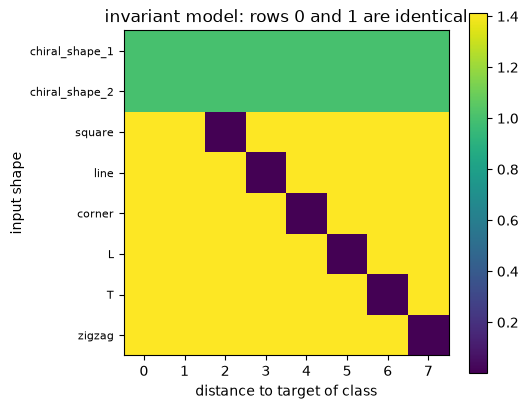

In [16]:
# Train the model
hist_inv = train(model_inv)

# Compute the outputs of the model after training
out_inv = model_inv(pos, edge_index, batch, 8)

# Classify the outputs
pred = classify(out_inv)

# Print the results
print(f"final loss {hist_inv[-1]:.4f},  accuracy {accuracy(out_inv):.3f}")
print(f"predictions: {pred.tolist()}  (true: {list(range(8))})")
print(f"trained:    max |f(chiral_1) - f(chiral_2)| = {(out_inv[0]-out_inv[1]).abs().max():.1e}")

# Visualize the distance matrix between the model outputs and the target vectors
fig, ax = plt.subplots(figsize=(5.5, 4.5))
D = (out_inv[:, None, :] - targets[None, :, :]).norm(dim=-1).detach()
im = ax.imshow(D, cmap="viridis")
ax.set_xticks(range(8), range(8))
ax.set_yticks(range(8), TETRIS_LABELS, fontsize=8)
ax.set_xlabel("distance to target of class")
ax.set_ylabel("input shape")
ax.set_title("invariant model: rows 0 and 1 are identical")
fig.colorbar(im)
fig.tight_layout()
plt.show()

The two top rows of the distance matrix are *pixel-identical*: whatever class
wins for `chiral_shape_1` wins for `chiral_shape_2` too. Therefore, at least one
of them is always wrong (here the model parks both at the loss-minimizing
compromise, pseudoscalar-slot $\approx 0$). Training longer, wider, or deeper
changes nothing: this is a symmetry issue, not an optimization failure.

## Experiment 2: One pseudoscalar in output irreps resolves chirality

We now set the `irreps_out` to `"1x0o + 6x0e"`. The only change is the *parity
label* of the first entry in the output irreps, which unlocks the `1e` $\otimes$
`1o` $\to$ `0o` path in layer 3.

parameters: 27941
final loss 4.86e-10,  accuracy 1.000
predictions: [0, 1, 2, 3, 4, 5, 6, 7]
pseudoscalar output: chiral_1 -> -1.000,  chiral_2 -> +1.000


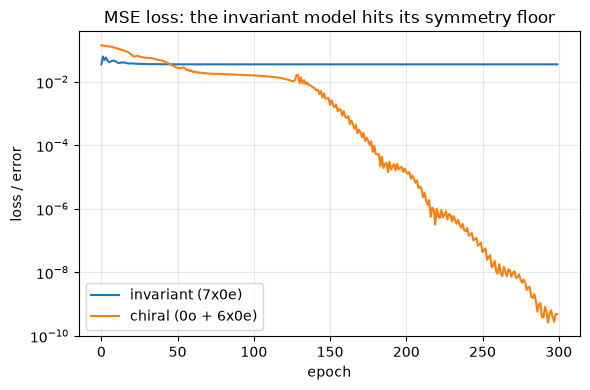

In [17]:
# Set the random seed for reproducibility
torch.manual_seed(1)

# Create an instance of the TetrisNet model with output irreps "1x0o + 6x0e"
# (one pseudoscalar and six true scalars)
model_chi = TetrisNet("1x0o + 6x0e", r_cut, avg_neighbors)
print(f"parameters: {sum(p.numel() for p in model_chi.parameters())}")

# Train the model
hist_chi = train(model_chi)

# Compute the outputs of the model after training
out_chi = model_chi(pos, edge_index, batch, 8)

# Classify the outputs
pred_chi = classify(out_chi)

# Print the results
print(f"final loss {hist_chi[-1]:.2e},  accuracy {accuracy(out_chi):.3f}")
print(f"predictions: {pred_chi.tolist()}")
print(f"pseudoscalar output: chiral_1 -> {out_chi[0,0]:+.3f},  chiral_2 -> {out_chi[1,0]:+.3f}")

# Visualize the training curves for both models
ax = plot_training_curves({"invariant (7x0e)": hist_inv, "chiral (0o + 6x0e)": hist_chi})
ax.set_title("MSE loss: the invariant model hits its symmetry floor")
ax.figure.tight_layout(); plt.show()

This model achieves 100% classification accuracy and the pseudoscalar comes out
equal and opposite on the mirror pair as its transformation law demands. The
invariant model's loss plateaus at exactly the variance it can never explain
($\tfrac{2 \cdot 1}{8 \cdot 7} \approx 0.036$: the $\pm 1$ targets of the pair,
unreachable, averaged over $8\times7$ outputs).

## The augmentation-free rotation test

Here, we trained the model on a dataset of shapes in a single orientation. We
now, test the network with shapes from the same dataset that have been rotated
and translated randomly. Our network should generalize to the rotated dataset as
well as it performed on the training and the unrotated test dataset.

In [19]:
# Set the random seed for reproducibility
torch.manual_seed(2)

# Evaluate the model on random rotations and translations of the input shapes
accs = []
for _ in range(20):
    # Generate a random rotation matrix and translation vector
    R, t = o3.rand_matrix(), torch.randn(3)
    
    # Apply the random rotation and translation to the positions of the Tetris shapes
    p_rot, ei_rot, b_rot = batch_graphs([p @ R.T + t for p in pos8], r_cut)
    
    # Compute the accuracy of the model on the rotated and translated shapes
    accs.append(accuracy(model_chi(p_rot, ei_rot, b_rot, 8)))

# Print the mean accuracy over the 20 random rotations and translations ...
print(f"accuracy over 20 random rotations + translations: {np.mean(accs):.3f}")

# ... and the party trick: Invert the shapes -> the chiral pair must swap labels
p_inv, ei_inv, b_inv = batch_graphs([-p for p in pos8], r_cut)
print(f"predictions on inverted shapes: {classify(model_chi(p_inv, ei_inv, b_inv, 8)).tolist()}")
print("  -> shapes 0 and 1 swap (a mirrored left-handed shape IS the right-handed one);")
print("     the 6 achiral shapes are their own mirror images and keep their labels.")

accuracy over 20 random rotations + translations: 1.000
predictions on inverted shapes: [1, 0, 2, 3, 4, 5, 6, 7]
  -> shapes 0 and 1 swap (a mirrored left-handed shape IS the right-handed one);
     the 6 achiral shapes are their own mirror images and keep their labels.


Perfect accuracy under transformations the model has *never seen* during its
training. Furthermore, the model doesn't fail under inversion applied to the
chiral pair: it correctly recognizes that the mirror of shape 0 is shape 1.

Our final sanity check is the full pipeline (positions $\to$ batched graph $\to$
3 convolutions $\to$ pooled prediction) E(3)-equivariance test performed on the
`TensorNet` with output irreps `1x0o + 6x0e`:

In [20]:
assert_model_equivariant(
    lambda p: model_chi(p, edge_index, batch, 8),
    pos, "1x0o + 6x0e",
)

equivariant!  (max error 4.663e-15 over random O(3) + translations elements)


4.6629367034256575e-15

## Summary

- Eight Tetris shapes, batched into one graph, classified end-to-end by three `TFNConv` blocks from Lesson 06a with `Gate` nonlinearities and a mean-pool readout.
- **Parity is expressiveness**: an O(3)-equivariant model with only `0e` outputs satisfies $f(-X) = f(X)$ *identically* — the chiral pair is indistinguishable before and after training (loss floor $\approx 0.036$, accuracy 75%).
- Declaring one output a **pseudoscalar `0o`** unlocks the parity chain `1o ⊗ 1o → 1e`, `1e ⊗ 1o → 0o` (three layers — chirality is a triple-product-order feature) → **100% accuracy**.
- Equivariance replaces augmentation: trained in one orientation, perfect on random rotations/translations; inversion *swaps* the chiral pair's predictions, exactly as the label covariance demands.

**Next:** Part III builds the invariant baselines properly — [07a:
SchNet](07a_schnet.ipynb) — before Part IV assembles NequIP, Allegro, and MACE
from the same `TFNConv` ingredients.

## Exercises

**1. Ablate the pseudovectors.** In `TetrisNet.gate2`, remove the `8x1e` from the gated irreps (and shrink the gates to `16x0e`). Retrain the `1x0o + 6x0e` model. What accuracy do you get, and why exactly?

<details><summary>Solution</summary>

Accuracy drops to the invariant model's 75% and the pseudoscalar output is *identically zero*: without `1e` (or `2o`) features in layer 2, layer 3 has no path of total parity `o` and $l=0$ — `FullyConnectedTensorProduct` simply finds no instructions ending in `0o`. The printed module shows the missing path; the loss plateaus at the same 0.036 floor. </details>

**2. Do we need $l_\mathrm{max} = 2$?** Rebuild everything with `l_max=1` (spherical harmonics `0e + 1o` only). Does the chiral model still reach 100%? Which paths produce the `1e` and `0o` now?

<details><summary>Solution</summary>

Yes — more slowly, but it works: `1e` comes only from `1o ⊗ 1o → 1e` (the cross product) in layer 2, and `0o` only from `1e ⊗ 1o → 0o` (the triple product) in layer 3 — exactly the two paths the original TFN code wires by hand ($\epsilon_{ijk}$ and the dot product). With `l_max=2` there are extra parity-odd routes: layer 2 can also build `2o` (via `1o ⊗ 2e → 2o`), which layer 3 closes with `2o ⊗ 2e → 0o` — more paths into the pseudoscalar, faster training. Try `steps=600` for a reliable 8/8 at `l_max=1`. </details>

**3. Prove the loss floor.** Show that for any inversion-invariant predictor $f$ the minimum of the MSE loss over the 8 shapes is $\frac{2}{8 \cdot 7}$, attained when the pseudoscalar slot predicts $0$ for the chiral pair.

<details><summary>Solution</summary>

For shapes 2–7 and all `0e` target components of shapes 0/1 the model can fit exactly (targets identical for the pair in those slots: all zeros). Only slot 0 of the pair is constrained: $f_0(X_0) = f_0(X_1) = y$ must compromise between targets $-1$ and $+1$; $\min_y [(y+1)^2 + (y-1)^2] = 2$ at $y = 0$. The mean over all $8 \times 7 = 56$ output entries gives $2/56 \approx 0.0357$ — precisely the plateau in the training-curve figure. </details>

## References

- [e3nn MRS Fall 2021 tutorial](https://e3nn.org/e3nn-tutorial-mrs-fall-2021/)
- [Geiger & Smidt, *e3nn: Euclidean Neural Networks* arXiv.2207.09453 (2021)](https://arxiv.org/pdf/2207.09453)
- [Thomas et al., *Tensor Field Networks* arXiv.1802.08219 (2018)](https://arxiv.org/pdf/1802.08219)